In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


plt.style.use("ggplot")



In [2]:
# Load Dataset
encounters = pd.read_csv("encounters.csv")
payers = pd.read_csv("payers.csv")

# Check first 5 rows
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [3]:
payers.head()

,Id,NAME,ADDRESS,CITY,STATE_HEADQUARTERED,ZIP,PHONE
0,b3221cfc-24fb-339e-823d-bc4136cbc4ed,Dual Eligible,7500 Security Blvd,Baltimore,MD,21244.0,1-877-267-2323
1,7caa7254-5050-3b5e-9eae-bd5ea30e809c,Medicare,7500 Security Blvd,Baltimore,MD,21244.0,1-800-633-4227
2,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,Medicaid,7500 Security Blvd,Baltimore,MD,21244.0,1-877-267-2323
3,d47b3510-2895-3b70-9897-342d681c769d,Humana,500 West Main St,Louisville,KY,40018.0,1-844-330-7799
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,Blue Cross Blue Shield,Michigan Plaza,Chicago,IL,60007.0,1-800-262-2583


In [4]:
# Convert START column to datetime
encounters["START"] = pd.to_datetime(encounters["START"])

In [5]:
# Set datetime index
encounters = encounters.set_index("START")

In [6]:
# Sort by date
encounters = encounters.sort_index()

encounters.head()

,Id,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
START,,,,,,,,,,,,,
2011-01-02 09:26:36+00:00,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
2011-01-03 05:44:39+00:00,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2011-01-03 14:32:11+00:00,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
2011-01-03 16:24:45+00:00,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
2011-01-03 17:36:53+00:00,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [7]:
## How many patient encounters occurred each month?

monthly_encounters = encounters.resample("ME").size()

print(monthly_encounters)

START
2011-01-31 00:00:00+00:00     86
2011-02-28 00:00:00+00:00     86
2011-03-31 00:00:00+00:00    129
2011-04-30 00:00:00+00:00    113
2011-05-31 00:00:00+00:00    131
                            ... 
2021-10-31 00:00:00+00:00    225
2021-11-30 00:00:00+00:00    267
2021-12-31 00:00:00+00:00    231
2022-01-31 00:00:00+00:00    219
2022-02-28 00:00:00+00:00      1
Freq: ME, Length: 134, dtype: int64


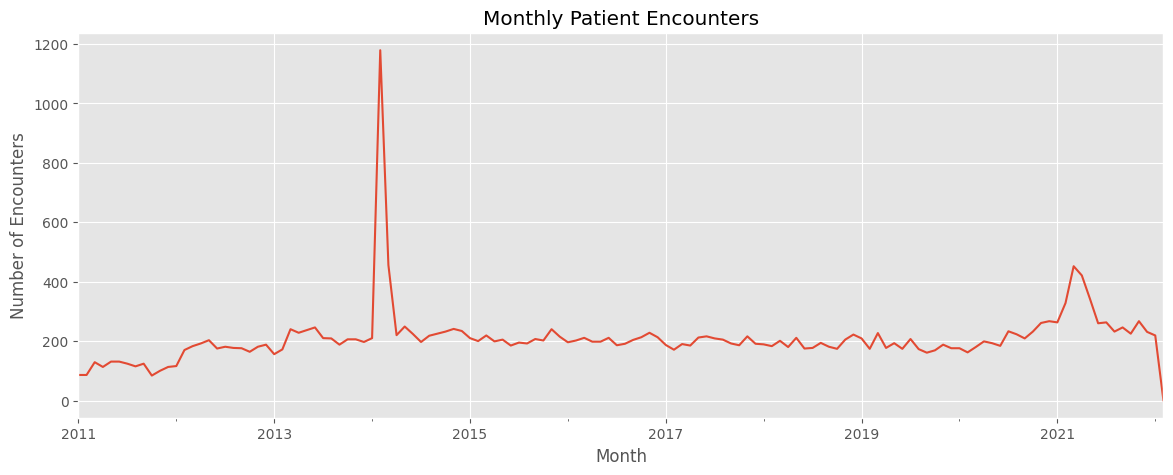

In [8]:
plt.figure(figsize=(14,5))
monthly_encounters.plot()

plt.title("Monthly Patient Encounters")
plt.xlabel("Month")
plt.ylabel("Number of Encounters")
plt.show()

In [9]:
## How many encounters occurred each year?
yearly_encounters = encounters.resample("YE").size()

print(yearly_encounters)

START
2011-12-31 00:00:00+00:00    1336
2012-12-31 00:00:00+00:00    2106
2013-12-31 00:00:00+00:00    2495
2014-12-31 00:00:00+00:00    3885
2015-12-31 00:00:00+00:00    2469
2016-12-31 00:00:00+00:00    2451
2017-12-31 00:00:00+00:00    2360
2018-12-31 00:00:00+00:00    2292
2019-12-31 00:00:00+00:00    2228
2020-12-31 00:00:00+00:00    2519
2021-12-31 00:00:00+00:00    3530
2022-12-31 00:00:00+00:00     220
Freq: YE-DEC, dtype: int64


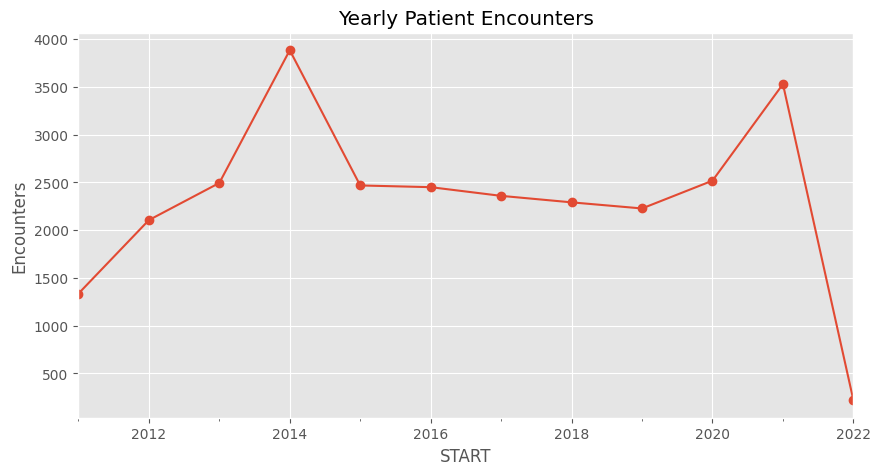

In [10]:
plt.figure(figsize=(10,5))
yearly_encounters.plot(marker='o')

plt.title("Yearly Patient Encounters")
plt.ylabel("Encounters")
plt.show()

In [11]:
## Which month had the highest number of encounters?

highest_month = monthly_encounters.idxmax()
highest_value = monthly_encounters.max()

print("Highest Month:", highest_month)
print("Encounters:", highest_value)

Highest Month: 2014-02-28 00:00:00+00:00
Encounters: 1179


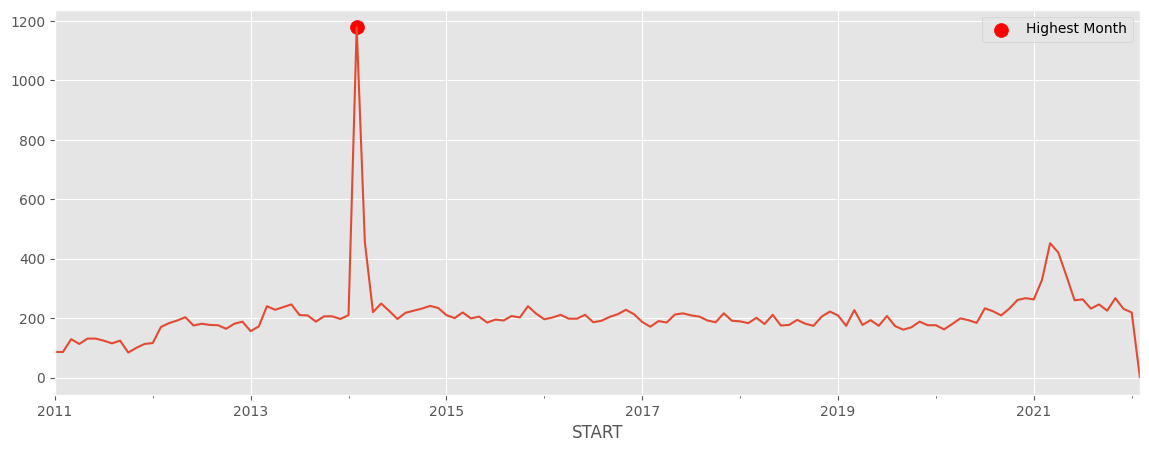

In [12]:
plt.figure(figsize=(14,5))
monthly_encounters.plot()

plt.scatter(
    highest_month,
    highest_value,
    color="red",
    s=100,
    label="Highest Month"
)

plt.legend()
plt.show()

In [13]:
## Which month had the fewest encounters?

lowest_month = monthly_encounters.idxmin()
lowest_value = monthly_encounters.min()

print(lowest_month)
print(lowest_value)

2022-02-28 00:00:00+00:00
1


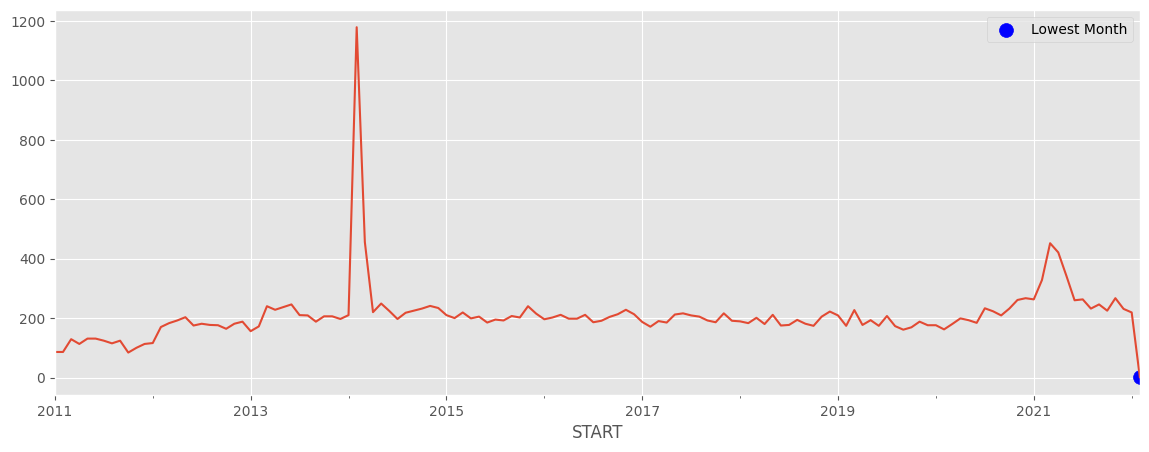

In [14]:
plt.figure(figsize=(14,5))
monthly_encounters.plot()

plt.scatter(
    lowest_month,
    lowest_value,
    color="blue",
    s=100,
    label="Lowest Month"
)

plt.legend()
plt.show()

In [15]:
## Calculate Month-over-Month (MoM) Growth
mom_growth = monthly_encounters.pct_change()*100

print(mom_growth.head())

START
2011-01-31 00:00:00+00:00          NaN
2011-02-28 00:00:00+00:00     0.000000
2011-03-31 00:00:00+00:00    50.000000
2011-04-30 00:00:00+00:00   -12.403101
2011-05-31 00:00:00+00:00    15.929204
Freq: ME, dtype: float64


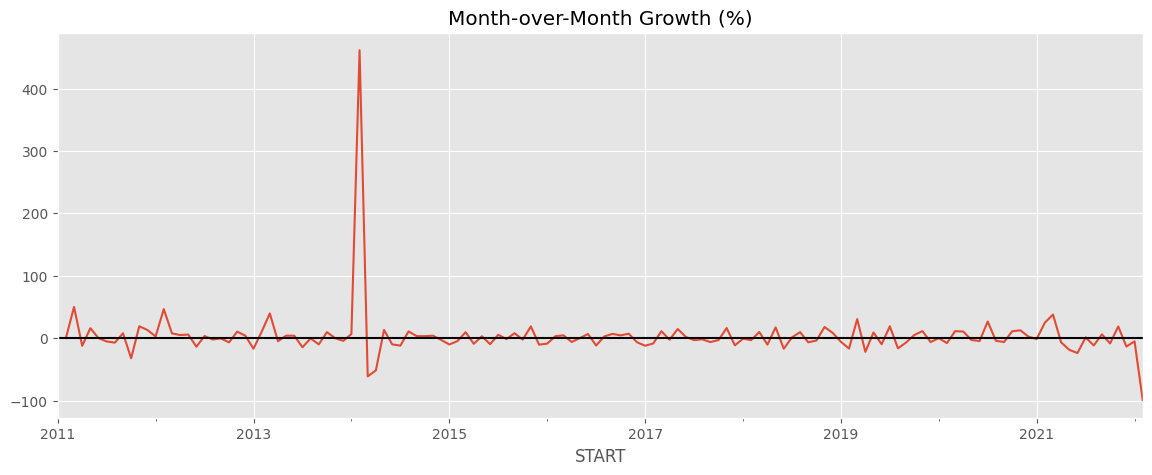

In [16]:
plt.figure(figsize=(14,5))
mom_growth.plot()

plt.axhline(0,color='black')

plt.title("Month-over-Month Growth (%)")

plt.show()

In [17]:
## Calculate the cumulative number of encounters over time

cumulative = monthly_encounters.cumsum()

print(cumulative.head())

START
2011-01-31 00:00:00+00:00     86
2011-02-28 00:00:00+00:00    172
2011-03-31 00:00:00+00:00    301
2011-04-30 00:00:00+00:00    414
2011-05-31 00:00:00+00:00    545
Freq: ME, dtype: int64


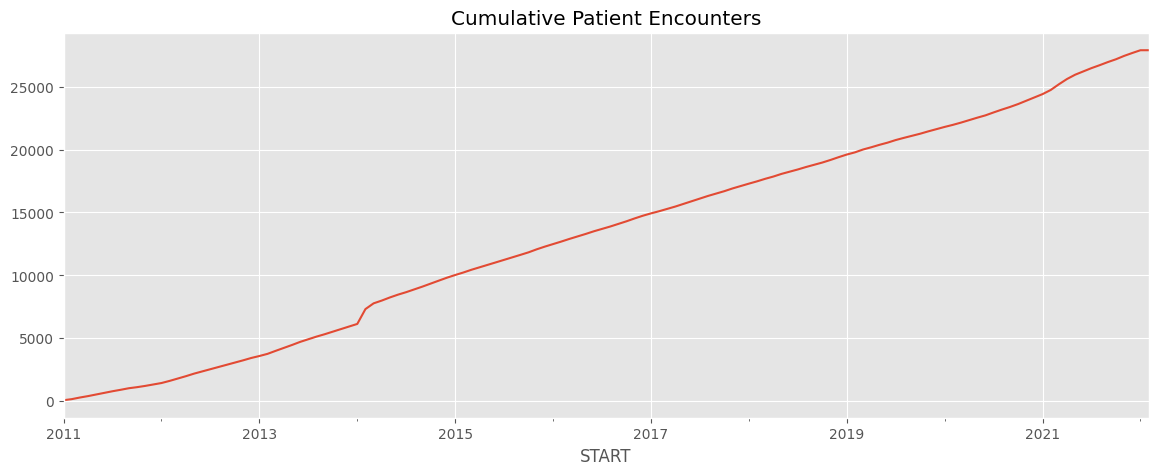

In [18]:
plt.figure(figsize=(14,5))

cumulative.plot()

plt.title("Cumulative Patient Encounters")

plt.show()

In [19]:
## Calculate monthly average daily encounters

daily = encounters.resample("D").size()

monthly_average = daily.resample("ME").mean()

print(monthly_average.head())

START
2011-01-31 00:00:00+00:00    2.866667
2011-02-28 00:00:00+00:00    3.071429
2011-03-31 00:00:00+00:00    4.161290
2011-04-30 00:00:00+00:00    3.766667
2011-05-31 00:00:00+00:00    4.225806
Freq: ME, dtype: float64


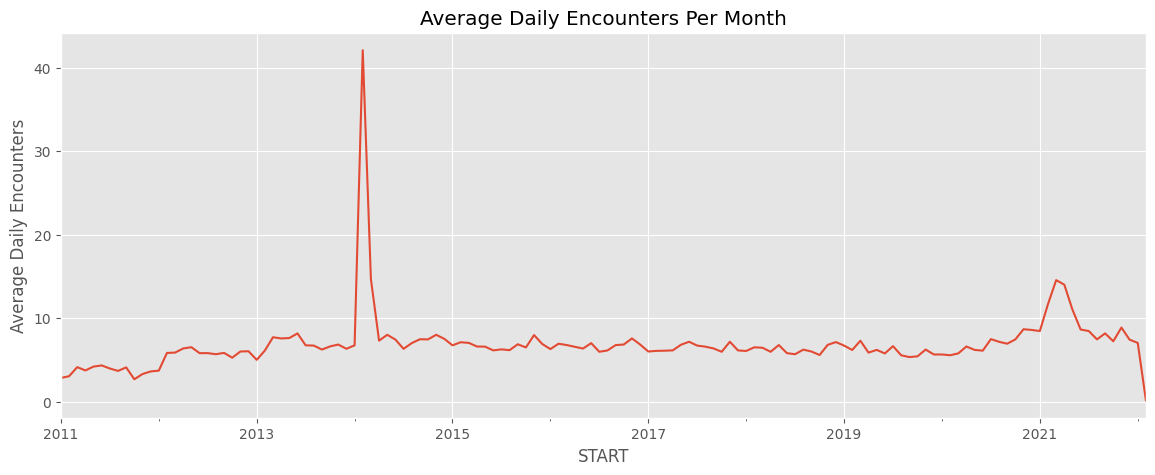

In [20]:
plt.figure(figsize=(14,5))

monthly_average.plot()

plt.title("Average Daily Encounters Per Month")

plt.ylabel("Average Daily Encounters")

plt.show()

In [21]:
## Calculate a 3-Month Moving Average

moving_avg3 = monthly_encounters.rolling(3).mean()

moving_avg3.head()

START
2011-01-31 00:00:00+00:00           NaN
2011-02-28 00:00:00+00:00           NaN
2011-03-31 00:00:00+00:00    100.333333
2011-04-30 00:00:00+00:00    109.333333
2011-05-31 00:00:00+00:00    124.333333
Freq: ME, dtype: float64

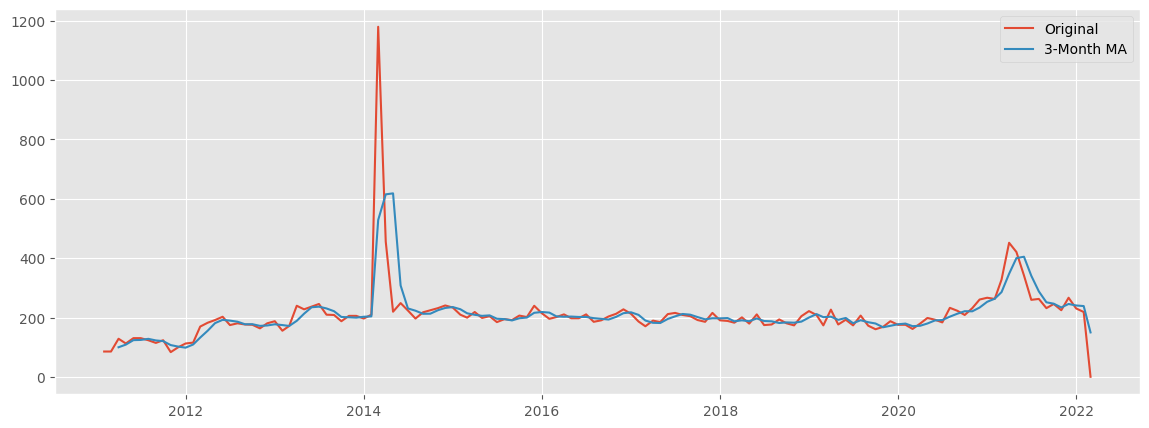

In [22]:
plt.figure(figsize=(14,5))

plt.plot(monthly_encounters,label="Original")

plt.plot(moving_avg3,label="3-Month MA")

plt.legend()

plt.show()

In [23]:
## Calculate a 6-Month Moving Average

moving_avg6 = monthly_encounters.rolling(6).mean()

moving_avg6.head(10)

START
2011-01-31 00:00:00+00:00           NaN
2011-02-28 00:00:00+00:00           NaN
2011-03-31 00:00:00+00:00           NaN
2011-04-30 00:00:00+00:00           NaN
2011-05-31 00:00:00+00:00           NaN
2011-06-30 00:00:00+00:00    112.666667
2011-07-31 00:00:00+00:00    119.000000
2011-08-31 00:00:00+00:00    123.833333
2011-09-30 00:00:00+00:00    123.000000
2011-10-31 00:00:00+00:00    118.166667
Freq: ME, dtype: float64

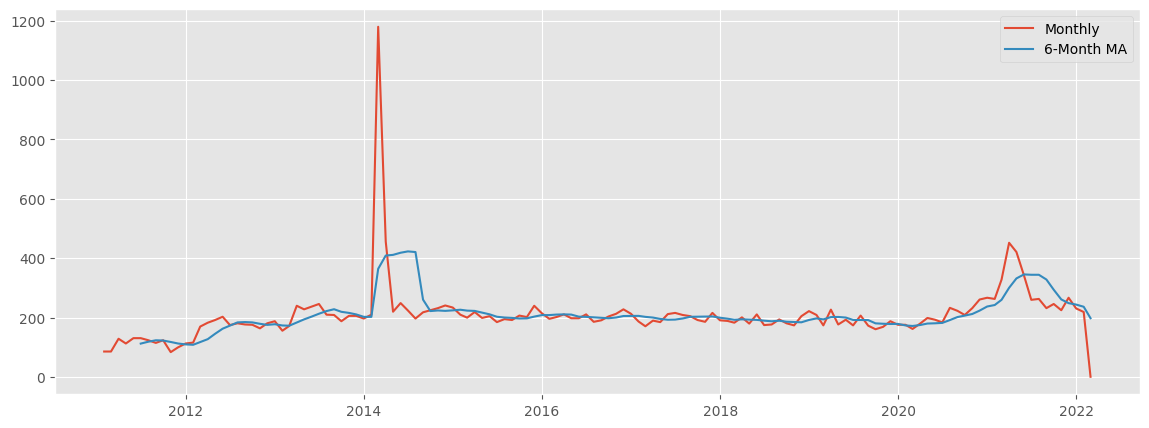

In [24]:
plt.figure(figsize=(14,5))

plt.plot(monthly_encounters,label="Monthly")

plt.plot(moving_avg6,label="6-Month MA")

plt.legend()

plt.show()

In [25]:
## Which weekday has the highest number of patient encounters?

weekday = encounters.copy()

weekday["Weekday"] = weekday.index.day_name()

weekday_counts = weekday.groupby("Weekday").size()

weekday_counts = weekday_counts.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(weekday_counts)

Weekday
Monday       4405
Tuesday      3644
Wednesday    4370
Thursday     3477
Friday       4059
Saturday     3963
Sunday       3973
dtype: int64


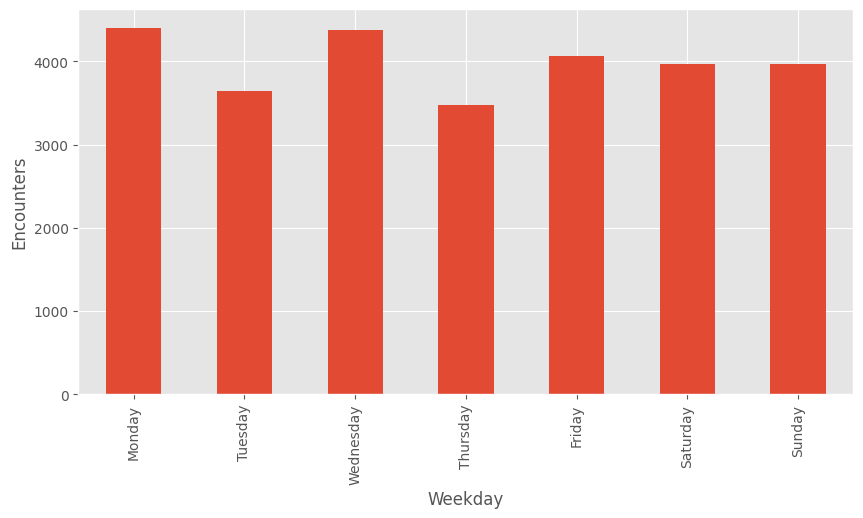

In [26]:
plt.figure(figsize=(10,5))

weekday_counts.plot(kind="bar")

plt.ylabel("Encounters")

plt.show()

In [27]:
## Which quarter has the highest number of encounters?

quarterly = encounters.resample("QE").size()

print(quarterly)

START
2011-03-31 00:00:00+00:00     301
2011-06-30 00:00:00+00:00     375
2011-09-30 00:00:00+00:00     363
2011-12-31 00:00:00+00:00     297
2012-03-31 00:00:00+00:00     469
2012-06-30 00:00:00+00:00     570
2012-09-30 00:00:00+00:00     534
2012-12-31 00:00:00+00:00     533
2013-03-31 00:00:00+00:00     568
2013-06-30 00:00:00+00:00     711
2013-09-30 00:00:00+00:00     607
2013-12-31 00:00:00+00:00     609
2014-03-31 00:00:00+00:00    1845
2014-06-30 00:00:00+00:00     693
2014-09-30 00:00:00+00:00     640
2014-12-31 00:00:00+00:00     707
2015-03-31 00:00:00+00:00     629
2015-06-30 00:00:00+00:00     589
2015-09-30 00:00:00+00:00     594
2015-12-31 00:00:00+00:00     657
2016-03-31 00:00:00+00:00     609
2016-06-30 00:00:00+00:00     607
2016-09-30 00:00:00+00:00     581
2016-12-31 00:00:00+00:00     654
2017-03-31 00:00:00+00:00     548
2017-06-30 00:00:00+00:00     613
2017-09-30 00:00:00+00:00     606
2017-12-31 00:00:00+00:00     593
2018-03-31 00:00:00+00:00     573
2018-06-

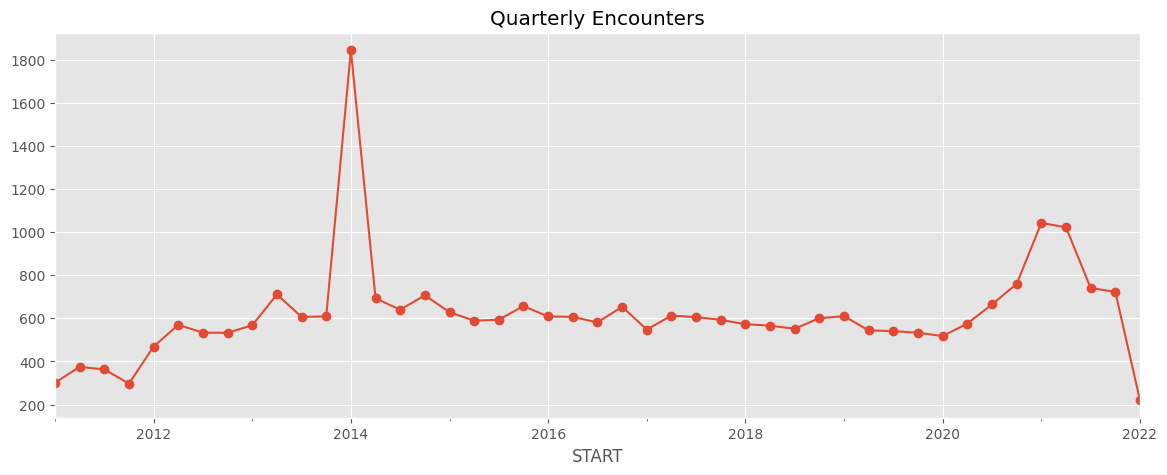

In [28]:
plt.figure(figsize=(14,5))

quarterly.plot(marker="o")

plt.title("Quarterly Encounters")

plt.show()

In [29]:
## Compare monthly encounters by year

monthly_year = encounters.groupby([
    encounters.index.year,
    encounters.index.month
]).size().unstack()

print(monthly_year)

START     1       2      3      4      5      6      7      8      9      10  \
START                                                                          
2011    86.0    86.0  129.0  113.0  131.0  131.0  124.0  115.0  124.0   84.0   
2012   116.0   170.0  183.0  192.0  203.0  175.0  181.0  177.0  176.0  164.0   
2013   156.0   172.0  240.0  228.0  237.0  246.0  210.0  209.0  188.0  206.0   
2014   210.0  1179.0  456.0  220.0  249.0  224.0  197.0  218.0  225.0  232.0   
2015   210.0   200.0  219.0  199.0  205.0  185.0  195.0  192.0  207.0  202.0   
2016   196.0   202.0  211.0  198.0  198.0  211.0  186.0  191.0  204.0  213.0   
2017   187.0   171.0  190.0  185.0  212.0  216.0  209.0  205.0  192.0  186.0   
2018   189.0   183.0  201.0  180.0  211.0  175.0  177.0  194.0  181.0  174.0   
2019   209.0   174.0  227.0  177.0  193.0  174.0  207.0  173.0  161.0  169.0   
2020   176.0   162.0  180.0  199.0  193.0  184.0  233.0  223.0  209.0  232.0   
2021   263.0   328.0  452.0  421.0  342.

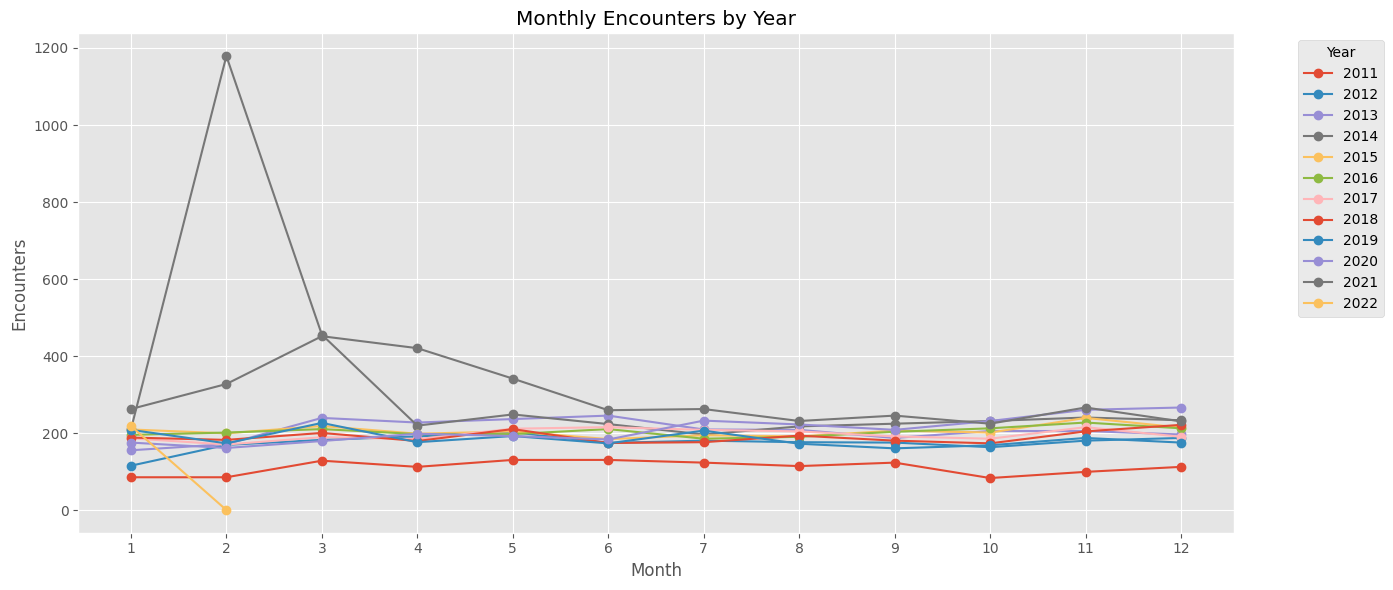

In [30]:
plt.figure(figsize=(14,6))

for year in monthly_year.index:
    plt.plot(
        monthly_year.columns,
        monthly_year.loc[year],
        marker='o',
        label=year
    )

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Encounters")

plt.title("Monthly Encounters by Year")

plt.legend(title="Year", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()

plt.show()

In [31]:
######

In [32]:
monthly = encounters.resample("ME").size()

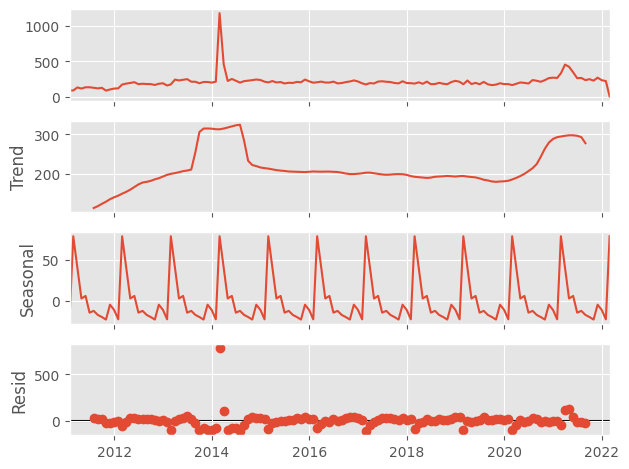

In [33]:
## Decompose the Monthly Time Series

decomposition = seasonal_decompose(
    monthly,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

In [34]:
## Is the Time Series Stationary? (ADF Test)

result = adfuller(monthly)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ADF Statistic : -7.462194943904888
p-value : 5.3177397432186865e-11
Series is Stationary


In [35]:
## Apply First-Order Differencing

monthly_diff = monthly.diff()

monthly_diff = monthly_diff.dropna()

monthly_diff.head()

START
2011-02-28 00:00:00+00:00     0.0
2011-03-31 00:00:00+00:00    43.0
2011-04-30 00:00:00+00:00   -16.0
2011-05-31 00:00:00+00:00    18.0
2011-06-30 00:00:00+00:00     0.0
Freq: ME, dtype: float64

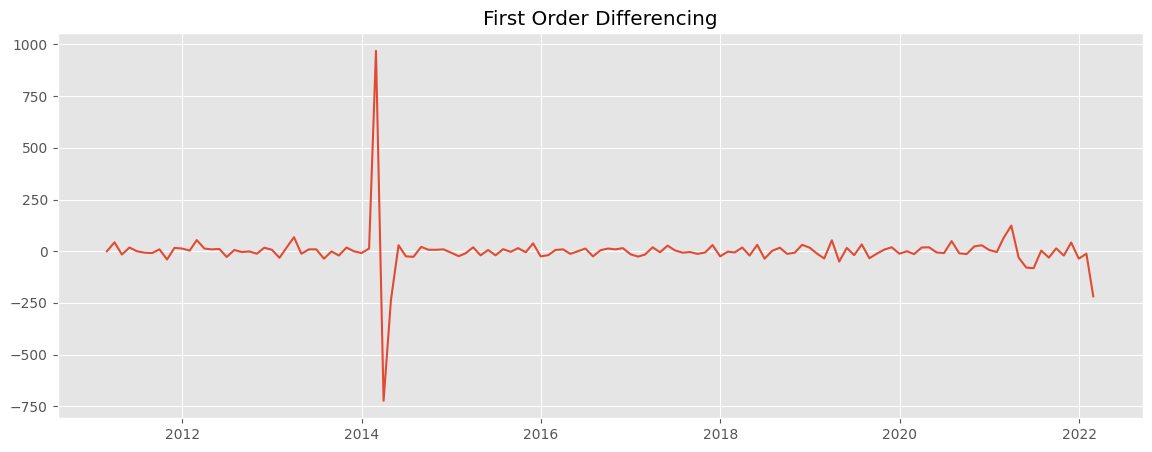

In [36]:
plt.figure(figsize=(14,5))
plt.plot(monthly_diff)

plt.title("First Order Differencing")
plt.show()

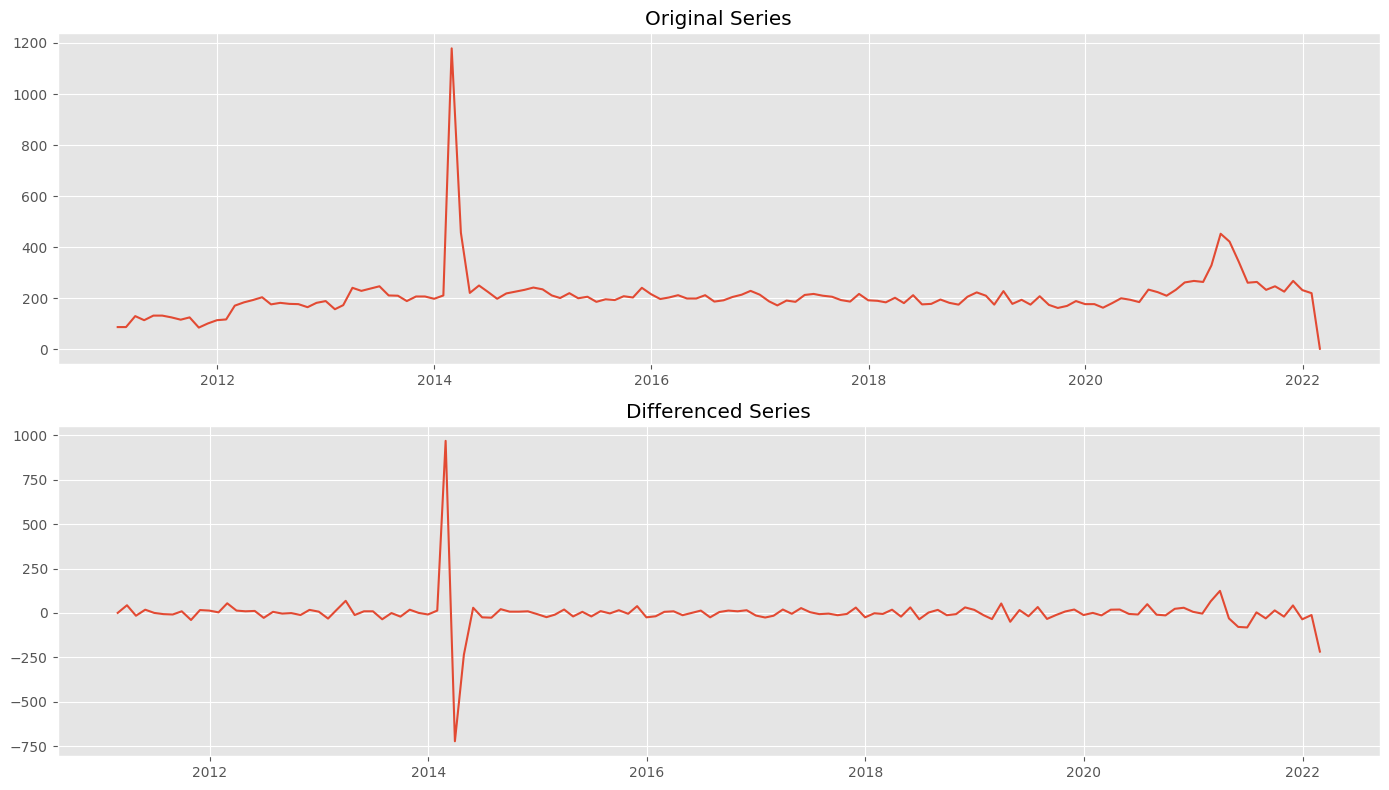

In [37]:
## Compare Original vs Differenced Series

fig, ax = plt.subplots(2,1, figsize=(14,8))

ax[0].plot(monthly)
ax[0].set_title("Original Series")

ax[1].plot(monthly_diff)
ax[1].set_title("Differenced Series")

plt.tight_layout()
plt.show()

In [38]:
## Creating Lag Features (not required here)

lag_df = pd.DataFrame()

lag_df["Current"] = monthly
lag_df["Lag1"] = monthly.shift(1)
lag_df["Lag3"] = monthly.shift(3)
lag_df["Lag6"] = monthly.shift(6)
lag_df["Lag12"] = monthly.shift(12)

lag_df.head(15)

,Current,Lag1,Lag3,Lag6,Lag12
START,,,,,
2011-01-31 00:00:00+00:00,86,NaN,NaN,NaN,NaN
2011-02-28 00:00:00+00:00,86,86.0,NaN,NaN,NaN
2011-03-31 00:00:00+00:00,129,86.0,NaN,NaN,NaN
2011-04-30 00:00:00+00:00,113,129.0,86.0,NaN,NaN
2011-05-31 00:00:00+00:00,131,113.0,86.0,NaN,NaN
2011-06-30 00:00:00+00:00,131,131.0,129.0,NaN,NaN
2011-07-31 00:00:00+00:00,124,131.0,113.0,86.0,NaN
2011-08-31 00:00:00+00:00,115,124.0,131.0,86.0,NaN
2011-09-30 00:00:00+00:00,124,115.0,131.0,129.0,NaN


In [39]:
## Calculate Rolling Mean

rolling_mean = monthly.rolling(12).mean()

rolling_mean.head()

START
2011-01-31 00:00:00+00:00   NaN
2011-02-28 00:00:00+00:00   NaN
2011-03-31 00:00:00+00:00   NaN
2011-04-30 00:00:00+00:00   NaN
2011-05-31 00:00:00+00:00   NaN
Freq: ME, dtype: float64

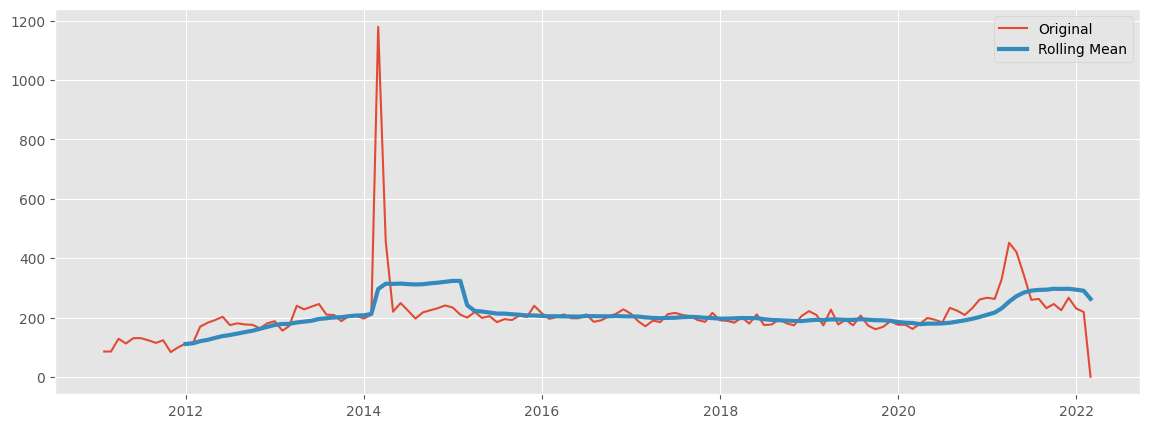

In [40]:
plt.figure(figsize=(14,5))

plt.plot(monthly,label="Original")

plt.plot(
    rolling_mean,
    linewidth=3,
    label="Rolling Mean"
)

plt.legend()
plt.show()

In [41]:
## Calculate Rolling Standard Deviation

rolling_std = monthly.rolling(12).std()

rolling_std.head()

START
2011-01-31 00:00:00+00:00   NaN
2011-02-28 00:00:00+00:00   NaN
2011-03-31 00:00:00+00:00   NaN
2011-04-30 00:00:00+00:00   NaN
2011-05-31 00:00:00+00:00   NaN
Freq: ME, dtype: float64

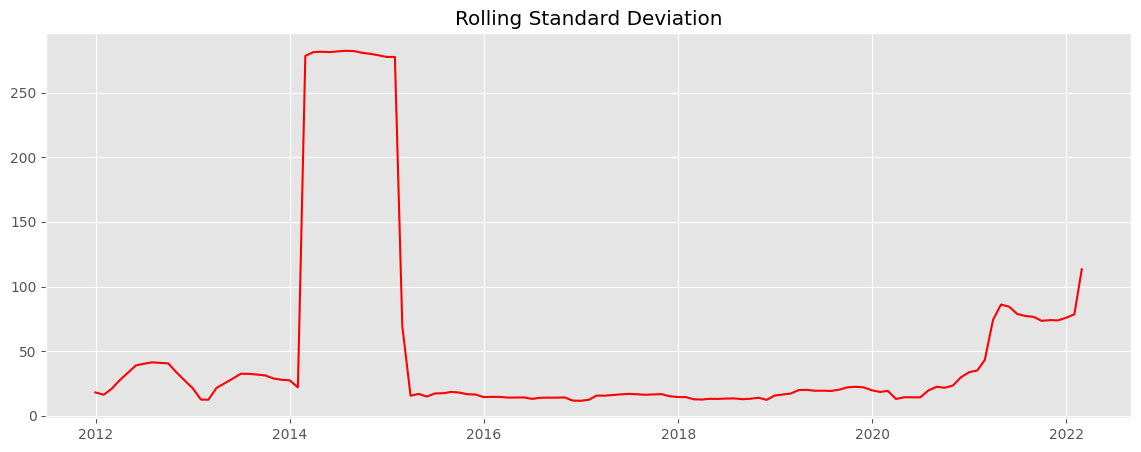

In [42]:
plt.figure(figsize=(14,5))

plt.plot(
    rolling_std,
    color="red"
)

plt.title("Rolling Standard Deviation")

plt.show()

In [43]:
## Monthly Encounter Trend by Organization

monthly_org = (
    encounters
    .groupby([
        pd.Grouper(freq="ME"),
        "ORGANIZATION"
    ])
    .size()
    .unstack(fill_value=0)
)

monthly_org.head()

ORGANIZATION,d78e84ec-30aa-3bba-a33a-f29a3a454662
START,
2011-01-31 00:00:00+00:00,86
2011-02-28 00:00:00+00:00,86
2011-03-31 00:00:00+00:00,129
2011-04-30 00:00:00+00:00,113
2011-05-31 00:00:00+00:00,131


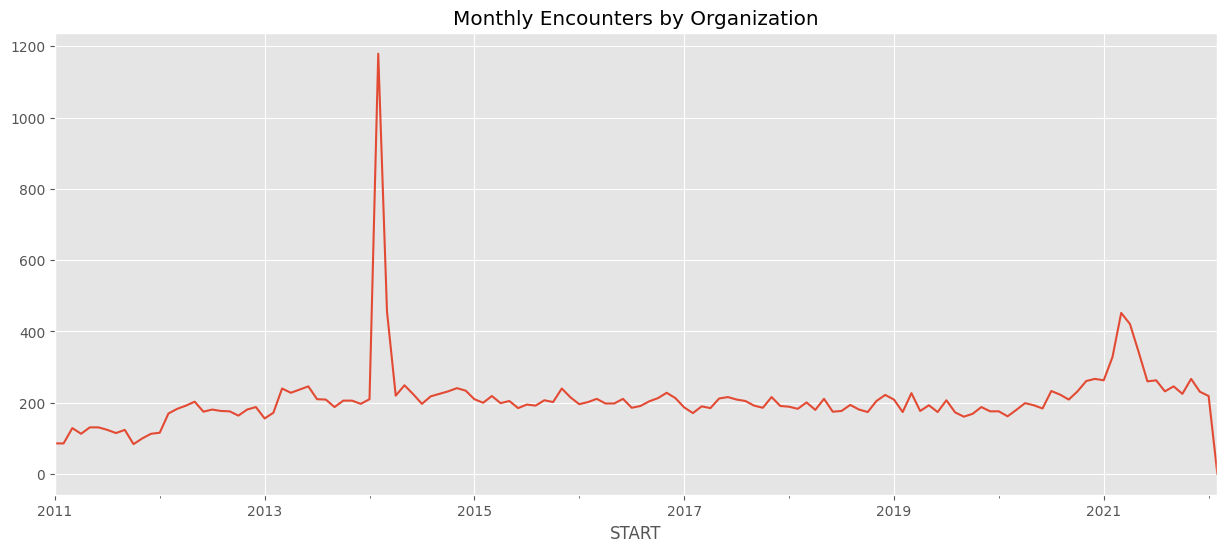

In [44]:
monthly_org.plot(
    figsize=(15,6),
    legend=False
)

plt.title("Monthly Encounters by Organization")

plt.show()

In [45]:
##  Top 5 Organizations by Total Encounters Over Time

top_org = (
    encounters["ORGANIZATION"]
    .value_counts()
    .head(5)
    .index
)

top_df = monthly_org[top_org]

top_df.head()

ORGANIZATION,d78e84ec-30aa-3bba-a33a-f29a3a454662
START,
2011-01-31 00:00:00+00:00,86
2011-02-28 00:00:00+00:00,86
2011-03-31 00:00:00+00:00,129
2011-04-30 00:00:00+00:00,113
2011-05-31 00:00:00+00:00,131


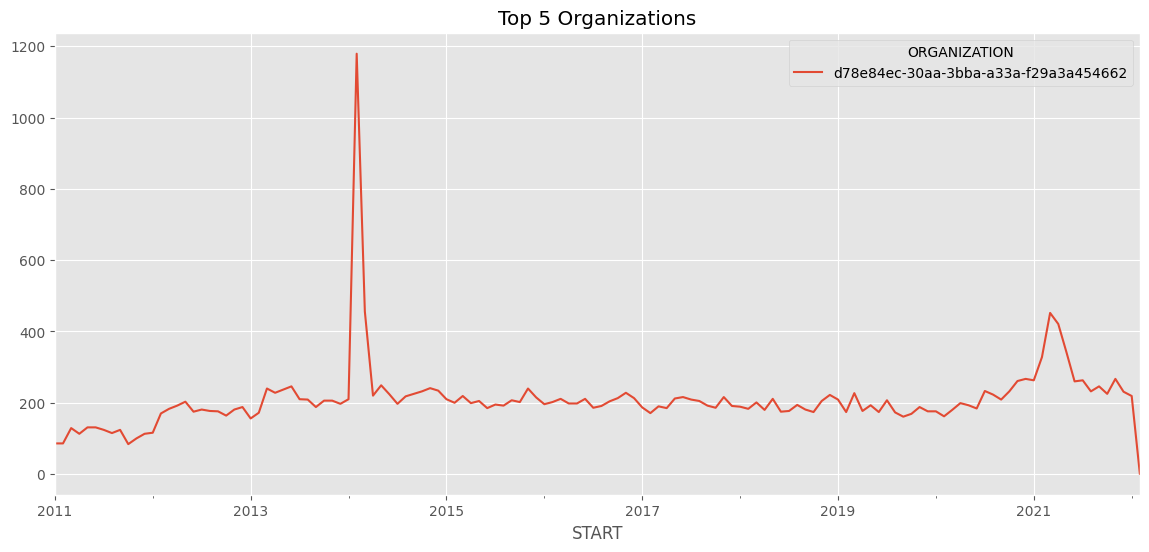

In [46]:
top_df.plot(figsize=(14,6))

plt.title("Top 5 Organizations")

plt.show()

In [47]:
##  Monthly Encounter Trend by Payer

merged = encounters.reset_index().merge(
    payers,
    left_on="PAYER",
    right_on="Id",
    how="left"
)

In [48]:
merged["START"] = pd.to_datetime(merged["START"])

payer_monthly = (
    merged
    .set_index("START")
    .groupby([
        pd.Grouper(freq="ME"),
        "NAME"
    ])
    .size()
    .unstack(fill_value=0)
)

payer_monthly.head()

NAME,Aetna,Anthem,Blue Cross Blue Shield,Cigna Health,Dual Eligible,Humana,Medicaid,Medicare,NO_INSURANCE,UnitedHealthcare
START,,,,,,,,,,
2011-01-31 00:00:00+00:00,3,3,1,2,3,2,5,30,35,2
2011-02-28 00:00:00+00:00,1,4,2,1,1,1,4,44,24,4
2011-03-31 00:00:00+00:00,1,3,2,3,3,2,2,58,32,23
2011-04-30 00:00:00+00:00,2,3,3,2,2,2,3,46,28,22
2011-05-31 00:00:00+00:00,1,1,3,2,3,19,5,45,31,21


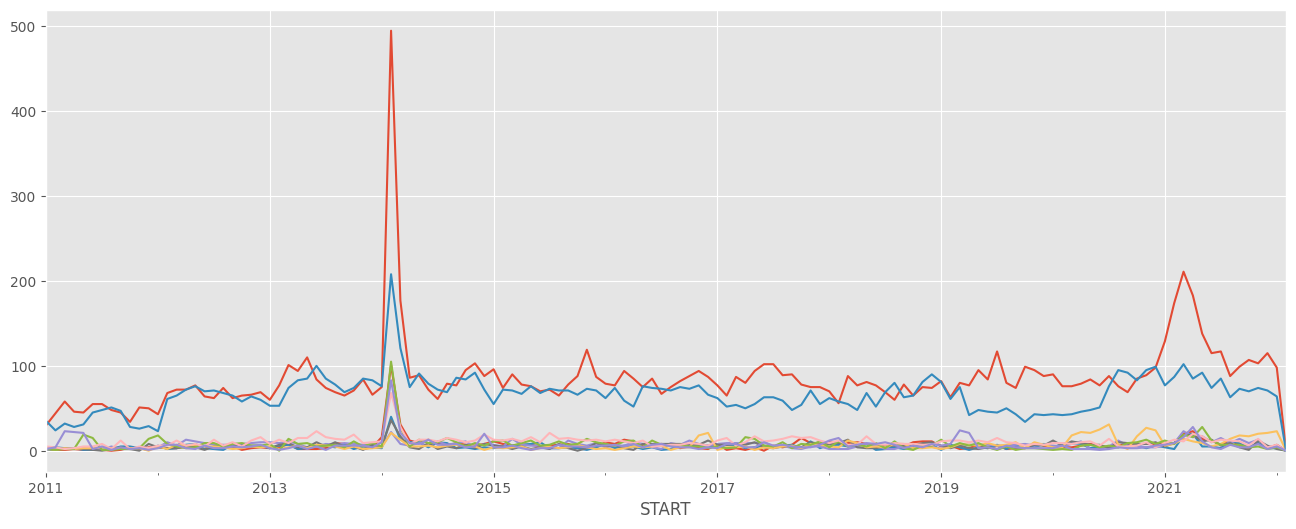

In [49]:
payer_monthly.plot(
    figsize=(16,6),
    legend=False
)

plt.show()

In [50]:
print(encounters.columns)

Index(['Id', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER', 'ENCOUNTERCLASS',
       'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST',
       'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION'],
      dtype='object')


In [51]:
encounters.columns.tolist()

['Id',
 'STOP',
 'PATIENT',
 'ORGANIZATION',
 'PAYER',
 'ENCOUNTERCLASS',
 'CODE',
 'DESCRIPTION',
 'BASE_ENCOUNTER_COST',
 'TOTAL_CLAIM_COST',
 'PAYER_COVERAGE',
 'REASONCODE',
 'REASONDESCRIPTION']

In [52]:
print(encounters.index)

DatetimeIndex(['2011-01-02 09:26:36+00:00', '2011-01-03 05:44:39+00:00',
               '2011-01-03 14:32:11+00:00', '2011-01-03 16:24:45+00:00',
               '2011-01-03 17:36:53+00:00', '2011-01-03 19:08:16+00:00',
               '2011-01-03 22:39:50+00:00', '2011-01-04 14:49:55+00:00',
               '2011-01-04 15:13:10+00:00', '2011-01-05 04:02:09+00:00',
               ...
               '2022-01-28 07:13:29+00:00', '2022-01-28 13:12:16+00:00',
               '2022-01-28 20:01:36+00:00', '2022-01-28 23:41:33+00:00',
               '2022-01-29 06:19:36+00:00', '2022-01-29 11:42:06+00:00',
               '2022-01-29 20:12:53+00:00', '2022-01-29 20:35:37+00:00',
               '2022-01-29 20:35:37+00:00', '2022-02-05 20:27:36+00:00'],
              dtype='datetime64[ns, UTC]', name='START', length=27891, freq=None)


In [53]:
encounters.dtypes

Id                      object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PAYER                   object
ENCOUNTERCLASS          object
CODE                     int64
DESCRIPTION             object
BASE_ENCOUNTER_COST    float64
TOTAL_CLAIM_COST       float64
PAYER_COVERAGE         float64
REASONCODE             float64
REASONDESCRIPTION       object
dtype: object

In [54]:
## Monthly Encounter Trend by Encounter Class

encounter_class = (
    encounters
    .groupby([
        pd.Grouper(freq="ME"),
        "ENCOUNTERCLASS"
    ])
    .size()
    .unstack(fill_value=0)
)

encounter_class.head()

ENCOUNTERCLASS,ambulatory,emergency,inpatient,outpatient,urgentcare,wellness
START,,,,,,
2011-01-31 00:00:00+00:00,31,4,7,31,1,12
2011-02-28 00:00:00+00:00,36,3,8,19,4,16
2011-03-31 00:00:00+00:00,65,7,6,27,5,19
2011-04-30 00:00:00+00:00,54,6,5,28,1,19
2011-05-31 00:00:00+00:00,68,4,7,29,1,22


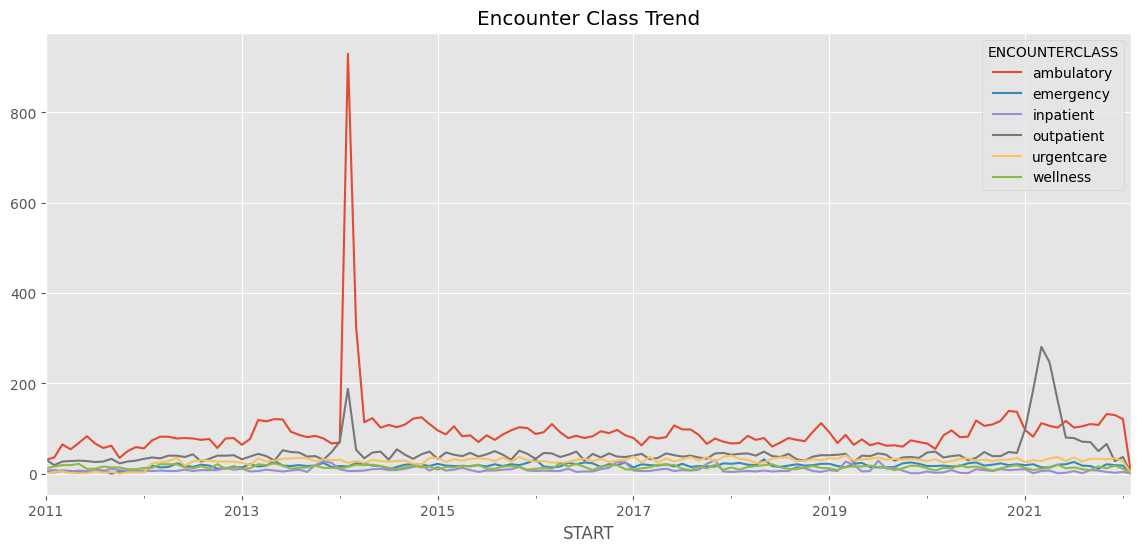

In [55]:
encounter_class.plot(figsize=(14,6))

plt.title("Encounter Class Trend")

plt.show()

In [56]:
## Monthly Average Encounter Duration

duration = encounters.copy()

duration["STOP"] = pd.to_datetime(duration["STOP"])

duration["Duration_Hours"] = (
    duration["STOP"] - duration.index
).dt.total_seconds()/3600

monthly_duration = (
    duration
    .resample("ME")
    ["Duration_Hours"]
    .mean()
)

monthly_duration.head()

START
2011-01-31 00:00:00+00:00    2.651618
2011-02-28 00:00:00+00:00    2.816424
2011-03-31 00:00:00+00:00    1.641191
2011-04-30 00:00:00+00:00    1.578609
2011-05-31 00:00:00+00:00    1.757937
Freq: ME, Name: Duration_Hours, dtype: float64

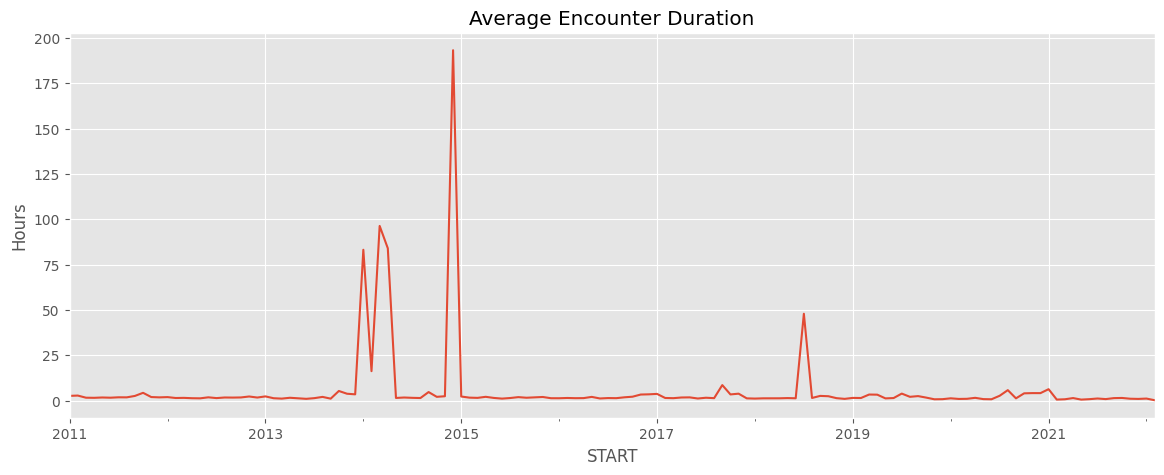

In [57]:
plt.figure(figsize=(14,5))

monthly_duration.plot()

plt.title("Average Encounter Duration")

plt.ylabel("Hours")

plt.show()

In [58]:
## Detect Monthly Outliers Using Z-Score

z = (
    monthly - monthly.mean()
) / monthly.std()

outliers = monthly[np.abs(z) > 2]

print(outliers)

START
2014-02-28 00:00:00+00:00    1179
2014-03-31 00:00:00+00:00     456
2021-03-31 00:00:00+00:00     452
2021-04-30 00:00:00+00:00     421
2022-02-28 00:00:00+00:00       1
dtype: int64


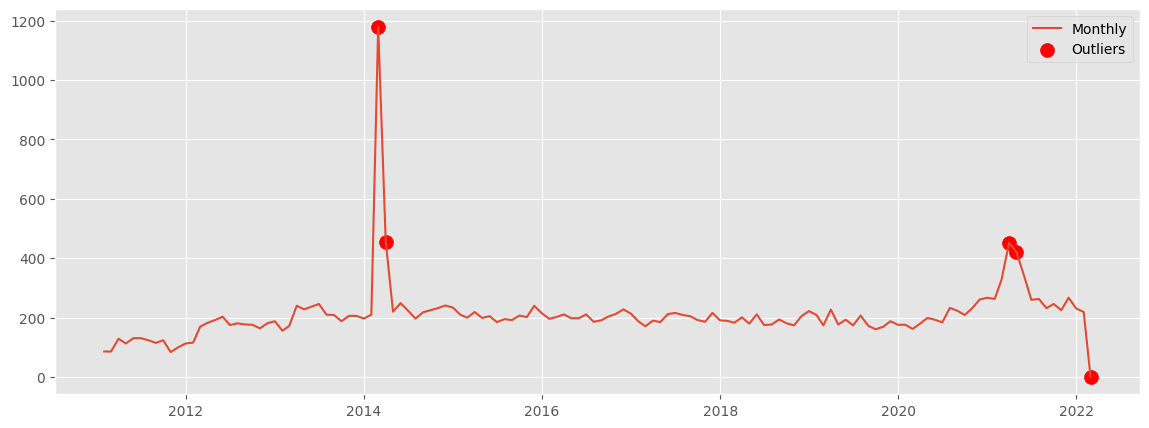

In [59]:
plt.figure(figsize=(14,5))

plt.plot(monthly,label="Monthly")

plt.scatter(
    outliers.index,
    outliers.values,
    color="red",
    s=100,
    label="Outliers"
)

plt.legend()

plt.show()

In [60]:
##

In [61]:
# Train-Test Split (Last 12 months as test)
train = monthly[:-12]
test = monthly[-12:]

In [62]:
## Forecast the Next 12 Months Using ARIMA

model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

forecast

2021-03-31 00:00:00+00:00    254.162606
2021-04-30 00:00:00+00:00    236.622031
2021-05-31 00:00:00+00:00    232.455149
2021-06-30 00:00:00+00:00    231.465277
2021-07-31 00:00:00+00:00    231.230127
2021-08-31 00:00:00+00:00    231.174265
2021-09-30 00:00:00+00:00    231.160995
2021-10-31 00:00:00+00:00    231.157842
2021-11-30 00:00:00+00:00    231.157093
2021-12-31 00:00:00+00:00    231.156916
2022-01-31 00:00:00+00:00    231.156873
2022-02-28 00:00:00+00:00    231.156863
Freq: ME, Name: predicted_mean, dtype: float64

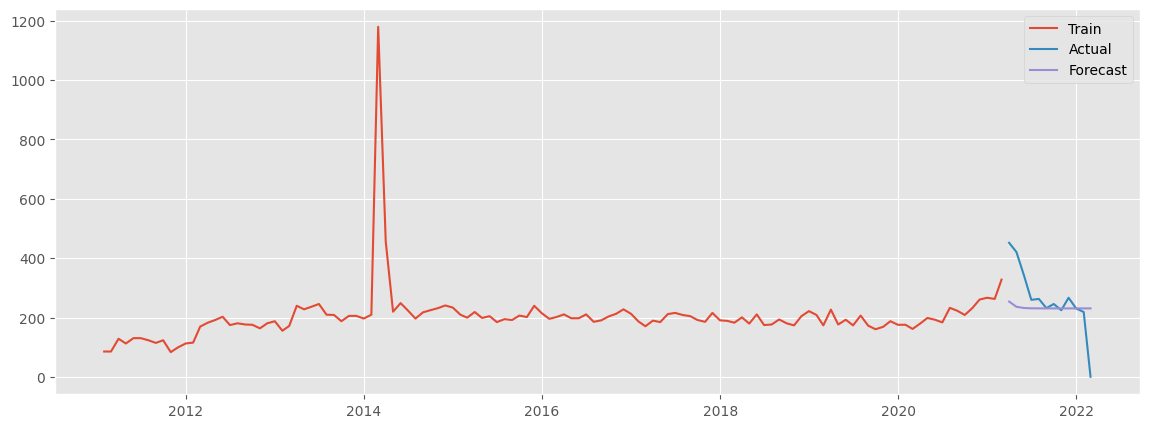

In [63]:
plt.figure(figsize=(14,5))

plt.plot(train,label="Train")
plt.plot(test,label="Actual")
plt.plot(test.index,forecast,label="Forecast")

plt.legend()
plt.show()

In [64]:
## Forecast Using SARIMA

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit()

sarima_forecast = sarima_fit.forecast(12)

C:\Users\Projit\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


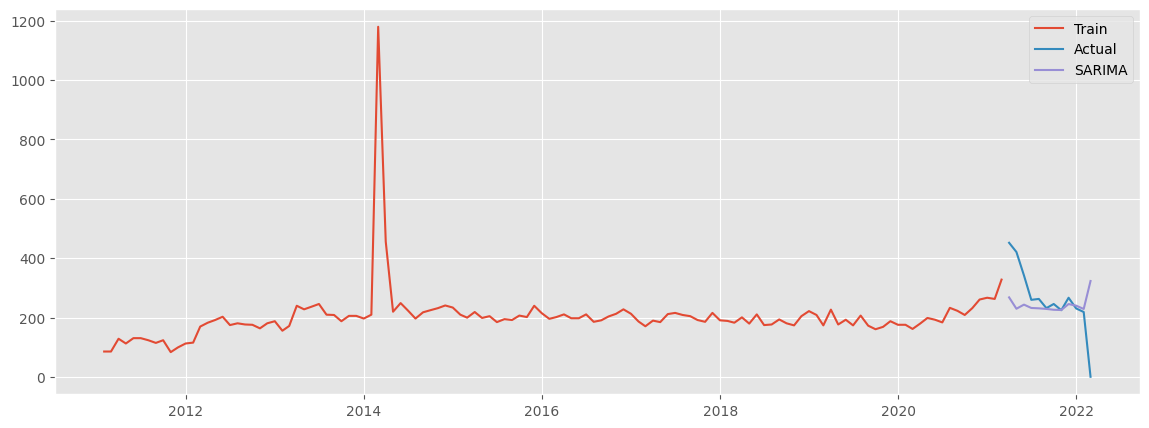

In [65]:
plt.figure(figsize=(14,5))

plt.plot(train,label="Train")

plt.plot(test,label="Actual")

plt.plot(test.index,sarima_forecast,label="SARIMA")

plt.legend()

plt.show()

In [66]:
print(model_fit.mle_retvals)

{'fopt': 5.92040274146653, 'gopt': array([ 3.71791486e-07, -1.65556457e-07,  8.08242362e-09]), 'fcalls': 84, 'warnflag': 0, 'converged': True, 'iterations': 18}


In [67]:
## Compare ARIMA and SARIMA Performance

comparison = pd.DataFrame({
    "Actual":test,
    "ARIMA":forecast,
    "SARIMA":sarima_forecast
})

comparison.head()

,Actual,ARIMA,SARIMA
2021-03-31 00:00:00+00:00,452,254.162606,268.238156
2021-04-30 00:00:00+00:00,421,236.622031,230.009107
2021-05-31 00:00:00+00:00,342,232.455149,243.854401
2021-06-30 00:00:00+00:00,260,231.465277,232.578072
2021-07-31 00:00:00+00:00,263,231.230127,231.395263


In [68]:
mae_arima = mean_absolute_error(test,forecast)
mae_sarima = mean_absolute_error(test,sarima_forecast)

rmse_arima = np.sqrt(mean_squared_error(test,forecast))
rmse_sarima = np.sqrt(mean_squared_error(test,sarima_forecast))

mape_arima = mean_absolute_percentage_error(test,forecast)
mape_sarima = mean_absolute_percentage_error(test,sarima_forecast)

print("ARIMA")
print(mae_arima,rmse_arima,mape_arima)

print()

print("SARIMA")
print(mae_sarima,rmse_sarima,mape_sarima)

ARIMA
71.01674588786592 108.6362455426052 19.322087023230093

SARIMA
76.47740090778449 124.67812762483199 26.994737462791097


In [69]:
#####

from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


In [70]:

prophet_df = monthly.reset_index()
prophet_df.columns = ["ds", "y"]

# Remove timezone
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq="ME")
forecast = model.predict(future)

11:59:42 - cmdstanpy - INFO - Chain [1] start processing


11:59:42 - cmdstanpy - INFO - Chain [1] done processing


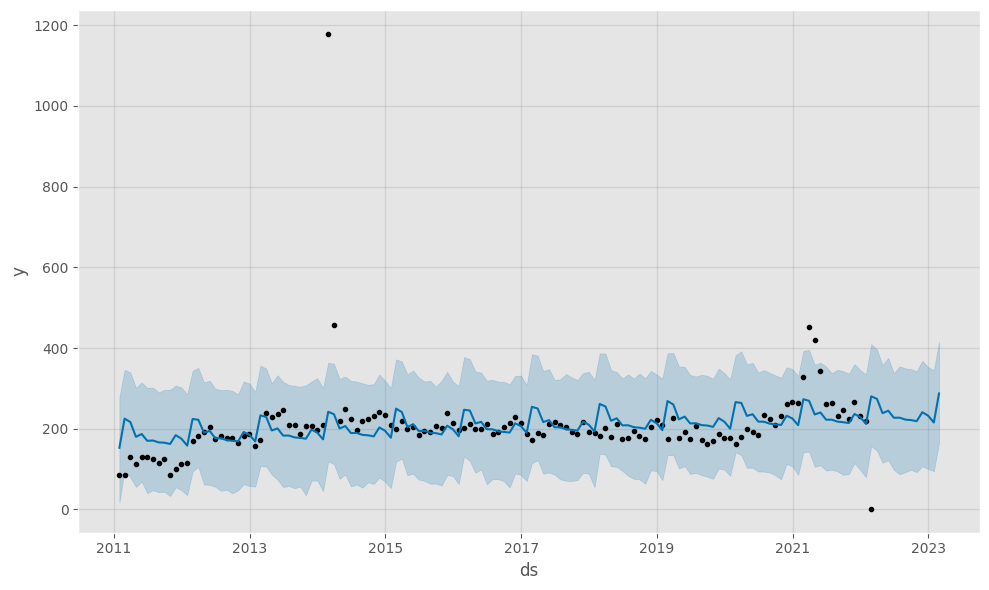

In [71]:
model.plot(forecast)

plt.show()

In [72]:
##  Forecast the Next 12 Months

forecast.tail(12)[
    ["ds","yhat","yhat_lower","yhat_upper"]
]

,ds,yhat,yhat_lower,yhat_upper
134,2022-03-31,273.905041,145.501522,396.444074
135,2022-04-30,238.616937,115.798057,357.539652
136,2022-05-31,244.449449,121.841725,375.463251
137,2022-06-30,227.083173,97.945796,337.361964
138,2022-07-31,227.268989,86.968284,354.550705
139,2022-08-31,222.522503,92.359840,349.382445
140,2022-09-30,221.347443,97.944780,347.661839
141,2022-10-31,218.671627,92.395467,342.605697
142,2022-11-30,240.758141,106.860394,368.002005
143,2022-12-31,232.439684,100.398584,352.744286


In [73]:
## Detect Monthly Anomalies Using Rolling Statistics

rolling_mean = monthly.rolling(12).mean()

rolling_std = monthly.rolling(12).std()

upper = rolling_mean + 2*rolling_std

lower = rolling_mean - 2*rolling_std

anomalies = monthly[
    (monthly>upper)|(monthly<lower)
]

anomalies

START
2012-02-29 00:00:00+00:00     170
2012-03-31 00:00:00+00:00     183
2013-03-31 00:00:00+00:00     240
2014-02-28 00:00:00+00:00    1179
2016-11-30 00:00:00+00:00     228
2020-07-31 00:00:00+00:00     233
2021-02-28 00:00:00+00:00     328
2021-03-31 00:00:00+00:00     452
2022-02-28 00:00:00+00:00       1
dtype: int64

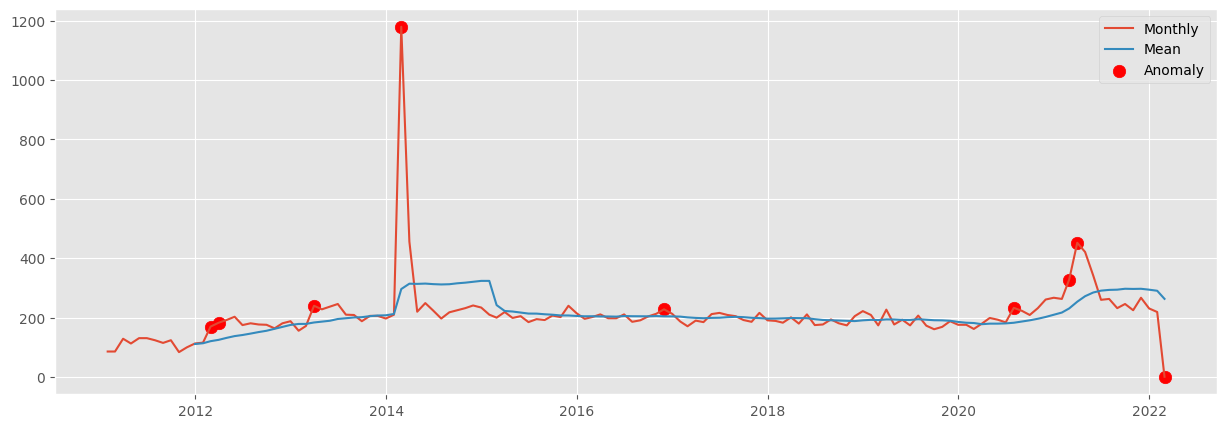

In [74]:
plt.figure(figsize=(15,5))

plt.plot(monthly,label="Monthly")

plt.plot(rolling_mean,label="Mean")

plt.scatter(
    anomalies.index,
    anomalies.values,
    color="red",
    s=80,
    label="Anomaly"
)

plt.legend()

plt.show()

In [75]:
## Forecast Encounters for Each Organization

organizations = encounters["ORGANIZATION"].dropna().unique()

results = {}

for org in organizations[:5]:

    ts = (
        encounters[
            encounters["ORGANIZATION"]==org
        ]
        .resample("ME")
        .size()
    )
    print(f"{org}: {len(ts)} months")
    
    if len(ts)>24:
        print("Model fitted")

        model = ARIMA(ts,order=(1,1,1))

        fit = model.fit()

        pred = fit.forecast(12)

        results[org] = pred
        
print(results)

d78e84ec-30aa-3bba-a33a-f29a3a454662: 134 months
Model fitted


{'d78e84ec-30aa-3bba-a33a-f29a3a454662': 2022-03-31 00:00:00+00:00    154.287473
2022-04-30 00:00:00+00:00    200.764510
2022-05-31 00:00:00+00:00    214.856432
2022-06-30 00:00:00+00:00    219.129128
2022-07-31 00:00:00+00:00    220.424617
2022-08-31 00:00:00+00:00    220.817411
2022-09-30 00:00:00+00:00    220.936507
2022-10-31 00:00:00+00:00    220.972617
2022-11-30 00:00:00+00:00    220.983566
2022-12-31 00:00:00+00:00    220.986886
2023-01-31 00:00:00+00:00    220.987892
2023-02-28 00:00:00+00:00    220.988198
Freq: ME, Name: predicted_mean, dtype: float64}


In [76]:
##  Compare Pre- and Post-Pandemic Trends

pre = monthly[:'2019']

post = monthly['2020':]

print(pre.describe())

print(post.describe())

count     108.000000
mean      200.203704
std       104.505490
min        84.000000
25%       176.000000
50%       194.500000
75%       211.000000
max      1179.000000
dtype: float64
count     26.000000
mean     241.115385
std       84.691122
min        1.000000
25%      201.500000
50%      232.000000
75%      263.000000
max      452.000000
dtype: float64


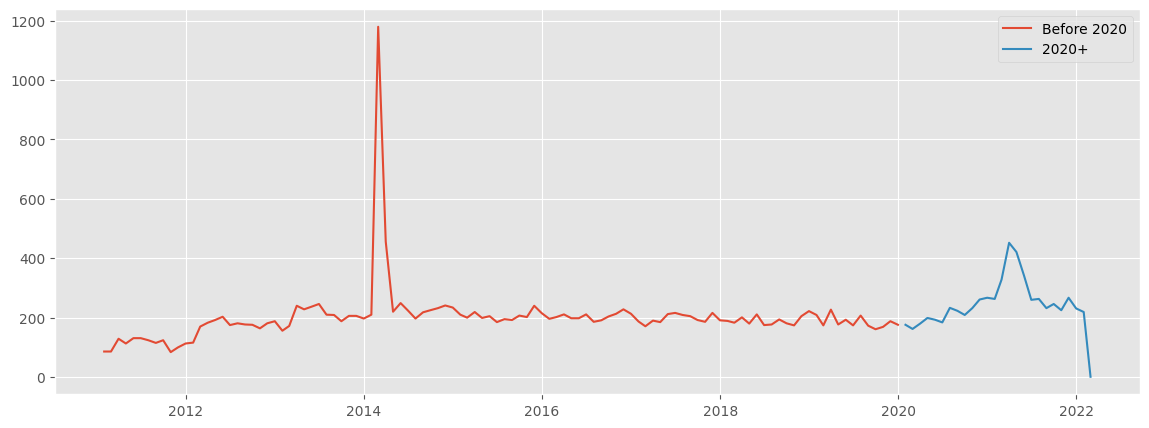

In [77]:
plt.figure(figsize=(14,5))

plt.plot(pre,label="Before 2020")

plt.plot(post,label="2020+")

plt.legend()

plt.show()

In [78]:
## Forecast Using XGBoost

ml = monthly.to_frame(name="Target")

ml["Lag1"] = ml["Target"].shift(1)

ml["Lag2"] = ml["Target"].shift(2)

ml["Lag3"] = ml["Target"].shift(3)

ml["Month"] = ml.index.month

ml["Quarter"] = ml.index.quarter

ml["Year"] = ml.index.year

ml["Rolling3"] = ml["Target"].rolling(3).mean()

ml = ml.dropna()

In [84]:
####

from xgboost import XGBRegressor

In [85]:
X = ml.drop(columns="Target")

y = ml["Target"]

train_size = len(X)-12

X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]

model = XGBRegressor()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

In [86]:
print("MAE:",mean_absolute_error(y_test,prediction))

print("RMSE:",np.sqrt(mean_squared_error(y_test,prediction)))

MAE: 66.0828628540039
RMSE: 87.080363722792


In [82]:
## a Complete Time Series Forecasting Pipeline

In [90]:

forecast = forecast["yhat"]

future_df = pd.DataFrame({
    "Date": future["ds"],
    "Forecast": forecast
})

future_df.to_csv("forecast.csv", index=False)